# pdb_tools — testes e validação

Valida a implementação Python de `pdb_tools.py` contra geometria conhecida
e contra a estrutura PDB **1PRB** (usada no pipeline original MATLAB).

| # | Célula | O que testa |
|---|--------|-------------|
| 1 | imports | setup |
| 2 | `find_angle` | ângulos exactos 0°/45°/90°/180° |
| 3 | `calc_dihedral` | geometria sintética + cutoff |
| 4 | `calc_dihedrals` | roundtrip aleatório + backbone sintético φ/ψ |
| 5 | download 1PRB | BioPython |
| 6 | `torsion()` | comprimentos de ligação, ω trans |
| 7 | `rotamer()` | contagem χ por resíduo |
| 8 | `extract()` | DataFrame completo |
| 9 | Ramachandran | scatter + hexbin |
| 10 | χ₁ histograma | por aminoácido |


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from Bio.PDB import PDBList, PDBParser

from protein_periodicity.pdb_tools import (
    find_angle, calc_dihedral, calc_dihedrals,
    torsion, rotamer, extract,
    CHIS, AMINO_ACIDS, CUTOFF,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

def chk(got, expected, tol=1e-6, label=""):
    err = abs(got - expected)
    ok  = err < tol
    print(f"{'✓' if ok else '✗'}  {label:35s}  got={got:+.6f}  exp={expected:+.6f}  Δ={err:.2e}")
    assert ok, f"{label}: {got} ≠ {expected}"

print("imports OK")

imports OK


## 1 · `find_angle`

In [2]:
i_ = np.array([1., 0., 0.])
j_ = np.array([0., 1., 0.])

chk(np.degrees(find_angle(i_, i_)),    0.0, tol=1e-9, label="paralelo  (0°)")
chk(np.degrees(find_angle(i_, j_)),   90.0, tol=1e-9, label="ortogonal (90°)")
chk(np.degrees(find_angle(i_, -i_)), 180.0, tol=1e-9, label="antiparalelo (180°)")
chk(np.degrees(find_angle(i_, i_+j_)), 45.0, tol=1e-6, label="diagonal  (45°)")

✓  paralelo  (0°)                       got=+0.000000  exp=+0.000000  Δ=0.00e+00
✓  ortogonal (90°)                      got=+90.000000  exp=+90.000000  Δ=0.00e+00
✓  antiparalelo (180°)                  got=+180.000000  exp=+180.000000  Δ=0.00e+00
✓  diagonal  (45°)                      got=+45.000000  exp=+45.000000  Δ=7.11e-15


## 2 · `calc_dihedral` — geometria sintética

Construção: eixo P2→P3 ao longo de **x**; P1 no plano **xy**;
P4 rodado `angle_deg` em torno do eixo.

In [3]:
def make_dihedral_pts(deg):
    p2 = np.array([0., 0., 0.])
    p3 = np.array([1., 0., 0.])
    p1 = np.array([0., 1., 0.])
    r  = np.radians(deg)
    p4 = p3 + np.array([0., np.cos(r), np.sin(r)])
    return p1, p2, p3, p4

for deg in [0., 60., 90., -90., 120., 180., -60.]:
    p1, p2, p3, p4 = make_dihedral_pts(deg)
    chk(np.degrees(calc_dihedral(p1, p2, p3, p4)), deg,
        tol=1e-5, label=f"diedro {deg:+.0f}°")

# cutoff: bond demasiado longo → NaN
p1, p2, p3, p4 = make_dihedral_pts(90.)
assert np.isnan(calc_dihedral(p1, p2, p3, p4 * 100, cutoff=CUTOFF))
print("✓  cutoff → NaN")

✓  diedro +0°                           got=+0.000000  exp=+0.000000  Δ=0.00e+00
✓  diedro +60°                          got=+60.000000  exp=+60.000000  Δ=7.11e-15
✓  diedro +90°                          got=+90.000000  exp=+90.000000  Δ=0.00e+00
✓  diedro -90°                          got=-90.000000  exp=-90.000000  Δ=0.00e+00
✓  diedro +120°                         got=+120.000000  exp=+120.000000  Δ=1.42e-14
✓  diedro +180°                         got=+180.000000  exp=+180.000000  Δ=0.00e+00
✓  diedro -60°                          got=-60.000000  exp=-60.000000  Δ=7.11e-15
✓  cutoff → NaN


## 3 · `calc_dihedrals` — roundtrip + backbone sintético

### 3a — roundtrip com pontos aleatórios
Qualquer 5-pla de pontos: `calc_dihedrals` deve dar o mesmo φ/ψ que `calc_dihedral` aplicado directamente.

In [4]:
rng = np.random.default_rng(42)
for trial in range(20):
    pts = [rng.random(3) * 5 for _ in range(5)]
    prev_c, curr_n, curr_ca, curr_c, next_n = pts

    # ground truth via calc_dihedral (sem cutoff)
    phi_gt = calc_dihedral(prev_c, curr_n, curr_ca, curr_c, cutoff=np.inf)
    psi_gt = calc_dihedral(curr_n, curr_ca, curr_c, next_n, cutoff=np.inf)

    phi_r, psi_r, *_ = calc_dihedrals(
        prev_c, curr_n, curr_ca, curr_c, next_n, cutoff=np.inf
    )
    assert abs(phi_r - phi_gt) < 1e-10, f"trial {trial}: phi mismatch"
    assert abs(psi_r - psi_gt) < 1e-10, f"trial {trial}: psi mismatch"

print("✓  calc_dihedrals roundtrip: 20 geometrias aleatórias OK")

✓  calc_dihedrals roundtrip: 20 geometrias aleatórias OK


### 3b — backbone sintético com φ/ψ conhecidos

Construção geométrica rigorosa usando rotação de Rodrigues:

**φ** = diedro(prev_C, curr_N, curr_CA, curr_C) — rotação em torno do eixo N→CA  
**ψ** = diedro(curr_N, curr_CA, curr_C, next_N) — rotação em torno do eixo CA→C

In [5]:
def build_backbone(phi_deg: float, psi_deg: float):
    """
    Constrói 5 átomos backbone (prevC, currN, currCA, currC, nextN)
    com o resíduo central tendo exactamente φ e ψ especificados.

    Derivação:
      - φ = diedro(prevC, currN, currCA, currC)  → roda prevC em torno do eixo N→CA
      - ψ = diedro(currN, currCA, currC, nextN)  → roda nextN em torno do eixo CA→C
    """
    phi = np.radians(phi_deg)
    psi = np.radians(psi_deg)

    dN_CA = 1.46   # Å
    dCA_C = 1.52   # Å
    dC_N  = 1.33   # Å (peptide bond)

    # Posições base: curr_CA na origem
    curr_ca = np.array([0., 0., 0.])
    curr_n  = np.array([0., dN_CA, 0.])                         # N ao longo de +y
    curr_c  = curr_ca + dCA_C * np.array(                       # C no plano xy
        [-np.sin(np.radians(111.)), -np.cos(np.radians(111.)), 0.])

    # --- prev_C para dado φ ---
    # φ = diedro(prevC, currN, currCA, currC)
    # Eixo de rotação: currN → currCA
    nca_hat = (curr_ca - curr_n) / np.linalg.norm(curr_ca - curr_n)
    # Referência: proj de (currC − currN) perp ao eixo (define φ=0)
    c_from_n  = curr_c - curr_n
    c_ref     = c_from_n - np.dot(c_from_n, nca_hat) * nca_hat
    c_ref_hat = c_ref / np.linalg.norm(c_ref)
    # Perpendicular no plano (right-hand em torno do eixo)
    perp_phi  = np.cross(c_ref_hat, nca_hat)
    prev_c    = curr_n + dC_N * (np.cos(phi) * c_ref_hat + np.sin(phi) * perp_phi)

    # --- next_N para dado ψ ---
    # ψ = diedro(currN, currCA, currC, nextN)
    # Eixo de rotação: currCA → currC
    cb        = curr_c - curr_ca
    cb_hat    = cb / np.linalg.norm(cb)
    # Referência: proj de (currN − currCA) perp ao eixo (define ψ=0)
    ab        = curr_n - curr_ca
    ab_ref    = ab - np.dot(ab, cb_hat) * cb_hat
    ab_ref_hat = ab_ref / np.linalg.norm(ab_ref)
    perp_psi  = np.cross(cb_hat, ab_ref_hat)
    next_n    = curr_c + dC_N * (np.cos(psi) * ab_ref_hat + np.sin(psi) * perp_psi)

    return prev_c, curr_n, curr_ca, curr_c, next_n


test_cases = [
    (-57.,  -47., "α-hélice"),
    (-120., 120., "β-folha"),
    ( 60.,   60., "L-α"),
    (  0.,    0., "eclipsado"),
    (-180., 180., "trans extremo"),
]

for phi_t, psi_t, label in test_cases:
    pc, cn, cca, cc, nn = build_backbone(phi_t, psi_t)
    phi_r, psi_r, dC_CA, dN_CA, *_ = calc_dihedrals(pc, cn, cca, cc, nn)
    chk(np.degrees(phi_r), phi_t, tol=0.5, label=f"{label} φ")
    chk(np.degrees(psi_r), psi_t, tol=0.5, label=f"{label} ψ")
    print(f"   dC_CA={dC_CA:.4f} Å (esperado ≈1.52)  dN_CA={dN_CA:.4f} Å (esperado ≈1.46)")
    print()

✓  α-hélice φ                           got=-57.000000  exp=-57.000000  Δ=7.11e-15
✓  α-hélice ψ                           got=-47.000000  exp=-47.000000  Δ=1.42e-14
   dC_CA=1.5200 Å (esperado ≈1.52)  dN_CA=1.4600 Å (esperado ≈1.46)

✓  β-folha φ                            got=-120.000000  exp=-120.000000  Δ=1.42e-14
✓  β-folha ψ                            got=+120.000000  exp=+120.000000  Δ=1.42e-14
   dC_CA=1.5200 Å (esperado ≈1.52)  dN_CA=1.4600 Å (esperado ≈1.46)

✓  L-α φ                                got=+60.000000  exp=+60.000000  Δ=7.11e-15
✓  L-α ψ                                got=+60.000000  exp=+60.000000  Δ=1.42e-14
   dC_CA=1.5200 Å (esperado ≈1.52)  dN_CA=1.4600 Å (esperado ≈1.46)

✓  eclipsado φ                          got=+0.000000  exp=+0.000000  Δ=0.00e+00
✓  eclipsado ψ                          got=+0.000000  exp=+0.000000  Δ=0.00e+00
   dC_CA=1.5200 Å (esperado ≈1.52)  dN_CA=1.4600 Å (esperado ≈1.46)

✓  trans extremo φ                      got=-180.000000  exp

## 4 · Download e parse da PDB 1PRB

In [6]:
PDB_ID  = "1PRB"
PDB_DIR = "../proteinData"

pdbl      = PDBList(verbose=False)
pdb_path  = pdbl.retrieve_pdb_file(PDB_ID, pdir=PDB_DIR, file_format="pdb")
print(f"Ficheiro: {pdb_path}")

parser    = PDBParser(QUIET=True)
structure = parser.get_structure(PDB_ID, pdb_path)

n_models = len(list(structure.get_models()))
print(f"Modelos: {n_models}")
for chain in structure[0]:
    res = [r for r in chain if r.id[0] == ' ']
    print(f"  Cadeia {chain.id}: {len(res)} resíduos standard")

Ficheiro: ../proteinData/pdb1prb.ent
Modelos: 1
  Cadeia A: 53 resíduos standard


## 5 · `torsion()` — extração backbone

In [7]:
tor    = torsion(structure)
df_tor = pd.DataFrame(tor)

print(f"Total resíduos : {len(df_tor)}")
print(f"Com φ/ψ válidos: {df_tor['phi'].notna().sum()}")
print()
print(
    df_tor.dropna(subset=["phi"])
    .assign(
        phi_deg  = lambda d: np.degrees(d.phi).round(1),
        psi_deg  = lambda d: np.degrees(d.psi).round(1),
        omega_deg= lambda d: np.degrees(d.omega).round(1),
    )[["resName","resSeq","chain","phi_deg","psi_deg","omega_deg","dC_CA","dN_CA"]]
    .head(10)
    .to_string(index=False)
)

Total resíduos : 53
Com φ/ψ válidos: 51

resName  resSeq chain  phi_deg  psi_deg  omega_deg    dC_CA    dN_CA
    ILE       2     A     79.8     -5.8      179.9 1.526660 1.490660
    ASP       3     A    -34.4    -36.5      179.5 1.526064 1.486513
    GLN       4     A    -42.9    -19.0      179.1 1.525407 1.488861
    TRP       5     A    -26.3    -91.8      179.8 1.530853 1.484957
    LEU       6     A     36.7    -28.6      179.8 1.531099 1.490086
    LEU       7     A     83.6      4.8     -179.8 1.528672 1.489071
    LYS       8     A    -77.5     49.1     -179.7 1.528666 1.490630
    ASN       9     A   -111.8    -61.2      179.4 1.529426 1.488692
    ALA      10     A    -80.4      5.5      179.3 1.528868 1.488486
    LYS      11     A    -53.0    -76.8     -179.8 1.530046 1.488057


In [8]:
valid = df_tor.dropna(subset=["phi", "psi"])

print("=== Comprimentos de ligação (valores esperados da literatura) ===")
for col, exp in [("dC_CA", 1.52), ("dN_CA", 1.46), ("dP_plane", 1.33)]:
    m, s = valid[col].mean(), valid[col].std()
    print(f"  {col:12s}: mean={m:.4f}  std={s:.4f}  (esperado ≈ {exp})")

omega_deg = np.degrees(valid["omega"])
pct_trans = (omega_deg.abs() > 150).mean() * 100
print(f"\n  ω |ω|>150° (trans): {pct_trans:.1f}%  (esperado >90%)")
assert pct_trans > 90, f"Percentagem de trans inesperadamente baixa: {pct_trans:.1f}%"
print("✓  Comprimentos de ligação e ω dentro dos valores esperados")

=== Comprimentos de ligação (valores esperados da literatura) ===
  dC_CA       : mean=1.5292  std=0.0015  (esperado ≈ 1.52)
  dN_CA       : mean=1.4894  std=0.0014  (esperado ≈ 1.46)
  dP_plane    : mean=1.3046  std=0.0015  (esperado ≈ 1.33)

  ω |ω|>150° (trans): 100.0%  (esperado >90%)
✓  Comprimentos de ligação e ω dentro dos valores esperados


## 6 · `rotamer()` — ângulos χ laterais

In [9]:
rot    = rotamer(structure)
df_rot = pd.DataFrame(rot)

summary = (
    df_rot.groupby("resName")
    .agg(
        n          =("resSeq","count"),
        chi1_valid =("chi1", lambda x: x.notna().sum()),
        chi2_valid =("chi2", lambda x: x.notna().sum()),
        chi3_valid =("chi3", lambda x: x.notna().sum()),
        chi4_valid =("chi4", lambda x: x.notna().sum()),
    )
)
print(summary.to_string())

         n  chi1_valid  chi2_valid  chi3_valid  chi4_valid
resName                                                   
ALA      9           0           0           0           0
ASN      5           5           5           0           0
ASP      3           3           3           0           0
GLN      1           1           1           1           0
GLU      5           5           5           5           0
GLY      1           0           0           0           0
HIS      1           1           1           0           0
ILE      5           5           5           0           0
LEU      5           5           5           0           0
LYS      8           8           8           8           8
PHE      2           2           2           0           0
SER      1           1           0           0           0
THR      3           3           0           0           0
TRP      1           1           1           0           0
TYR      1           1           1           0          

In [10]:
# GLY e ALA não têm cadeia lateral → χ₁ deve ser NaN
for aa in ["GLY", "ALA"]:
    rows = df_rot[df_rot["resName"] == aa]
    if len(rows):
        assert rows["chi1"].isna().all(), f"{aa} não devia ter χ₁"
        print(f"✓  {aa}: chi1 = NaN em todos os {len(rows)} resíduos")

# ARG tem 4 χ
if "ARG" in df_rot["resName"].values:
    n_chi4 = df_rot[df_rot["resName"]=="ARG"]["chi4"].notna().sum()
    assert n_chi4 > 0, "ARG devia ter χ₄"
    print(f"✓  ARG: {n_chi4} resíduos com χ₄ definido")

✓  GLY: chi1 = NaN em todos os 1 resíduos
✓  ALA: chi1 = NaN em todos os 9 resíduos


## 7 · `extract()` — DataFrame backbone + side-chain

In [11]:
df = extract(structure)

print(f"Shape  : {df.shape}")
print(f"Colunas: {list(df.columns)}")
print()
print(df.describe().T[["count","mean","std","min","max"]].round(3))

Shape  : (51, 17)
Colunas: ['chain', 'resName', 'model', 'resSeq', 'phi', 'psi', 'omega', 'dC_CA', 'dN_CA', 'dN_C', 'dP_plane', 'ang_N_CA_C', 'tempFactor', 'chi1', 'chi2', 'chi3', 'chi4']

            count    mean     std    min     max
model        51.0   0.000   0.000  0.000   0.000
resSeq       51.0  27.000  14.866  2.000  52.000
phi          51.0  -1.104   0.862 -3.061   1.882
psi          51.0  -0.494   0.885 -3.124   2.601
omega        51.0   1.046   2.988 -3.142   3.142
dC_CA        51.0   1.529   0.002  1.525   1.532
dN_CA        51.0   1.489   0.001  1.484   1.491
dN_C         51.0   2.464   0.007  2.439   2.474
dP_plane     51.0   1.305   0.002  1.300   1.308
ang_N_CA_C   51.0   1.909   0.006  1.886   1.918
tempFactor   51.0   3.319   1.349  1.700   8.020
chi1         42.0  -0.920   1.680 -3.132   3.006
chi2         37.0  -0.247   2.113 -3.047   2.950
chi3         14.0   0.164   1.950 -2.826   3.009
chi4          8.0   0.366   2.443 -2.614   3.016


## 8 · Ramachandran plot

Equivalente ao gráfico principal do pipeline MATLAB (`Analysis.m`).

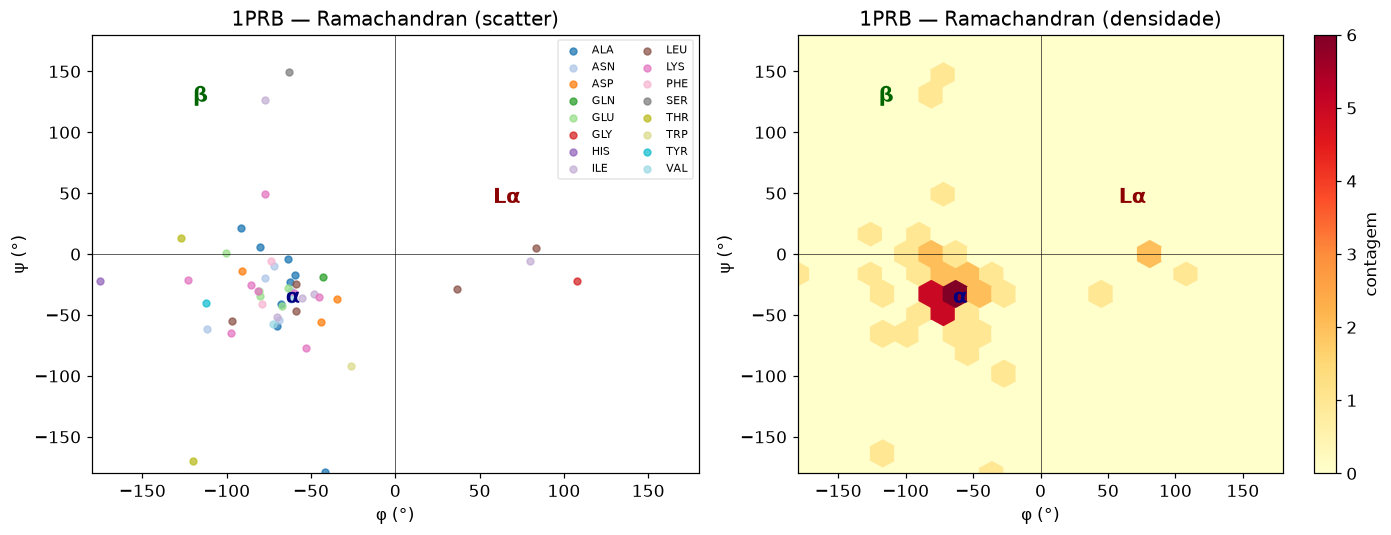

Guardado → images/1PRB_ramachandran.png


In [12]:
phi_d = np.degrees(df["phi"])
psi_d = np.degrees(df["psi"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatter colorido por aminoácido
ax = axes[0]
cmap = plt.get_cmap("tab20")
for k, aa in enumerate(sorted(df["resName"].unique())):
    m = df["resName"] == aa
    ax.scatter(phi_d[m], psi_d[m], s=20, alpha=0.75, label=aa,
               color=cmap(k / max(df["resName"].nunique()-1, 1)))
ax.set_xlim(-180, 180); ax.set_ylim(-180, 180)
ax.axhline(0, c='k', lw=0.4); ax.axvline(0, c='k', lw=0.4)
ax.set_xlabel("φ (°)"); ax.set_ylabel("ψ (°)")
ax.set_title(f"{PDB_ID} — Ramachandran (scatter)")
ax.legend(fontsize=7, ncol=2, loc="upper right", framealpha=0.5)

# mapa de densidade hexbin
ax = axes[1]
hb = ax.hexbin(phi_d, psi_d, gridsize=20, cmap="YlOrRd",
               extent=[-180,180,-180,180])
plt.colorbar(hb, ax=ax, label="contagem")
ax.set_xlim(-180, 180); ax.set_ylim(-180, 180)
ax.axhline(0, c='k', lw=0.4); ax.axvline(0, c='k', lw=0.4)
ax.set_xlabel("φ (°)"); ax.set_ylabel("ψ (°)")
ax.set_title(f"{PDB_ID} — Ramachandran (densidade)")

# anotações das regiões canónicas
regions = [("α", -65, -40, "navy"), ("β", -120, 125, "darkgreen"), ("Lα", 58, 42, "darkred")]
for label_, px, py, col in regions:
    for ax in axes:
        ax.annotate(label_, xy=(px, py), fontsize=14, color=col, fontweight="bold")

plt.tight_layout()
os.makedirs("../images", exist_ok=True)
plt.savefig("../images/1PRB_ramachandran.png", dpi=120, bbox_inches="tight")
plt.show()
print("Guardado → images/1PRB_ramachandran.png")

## 9 · Distribuição de χ₁ por aminoácido

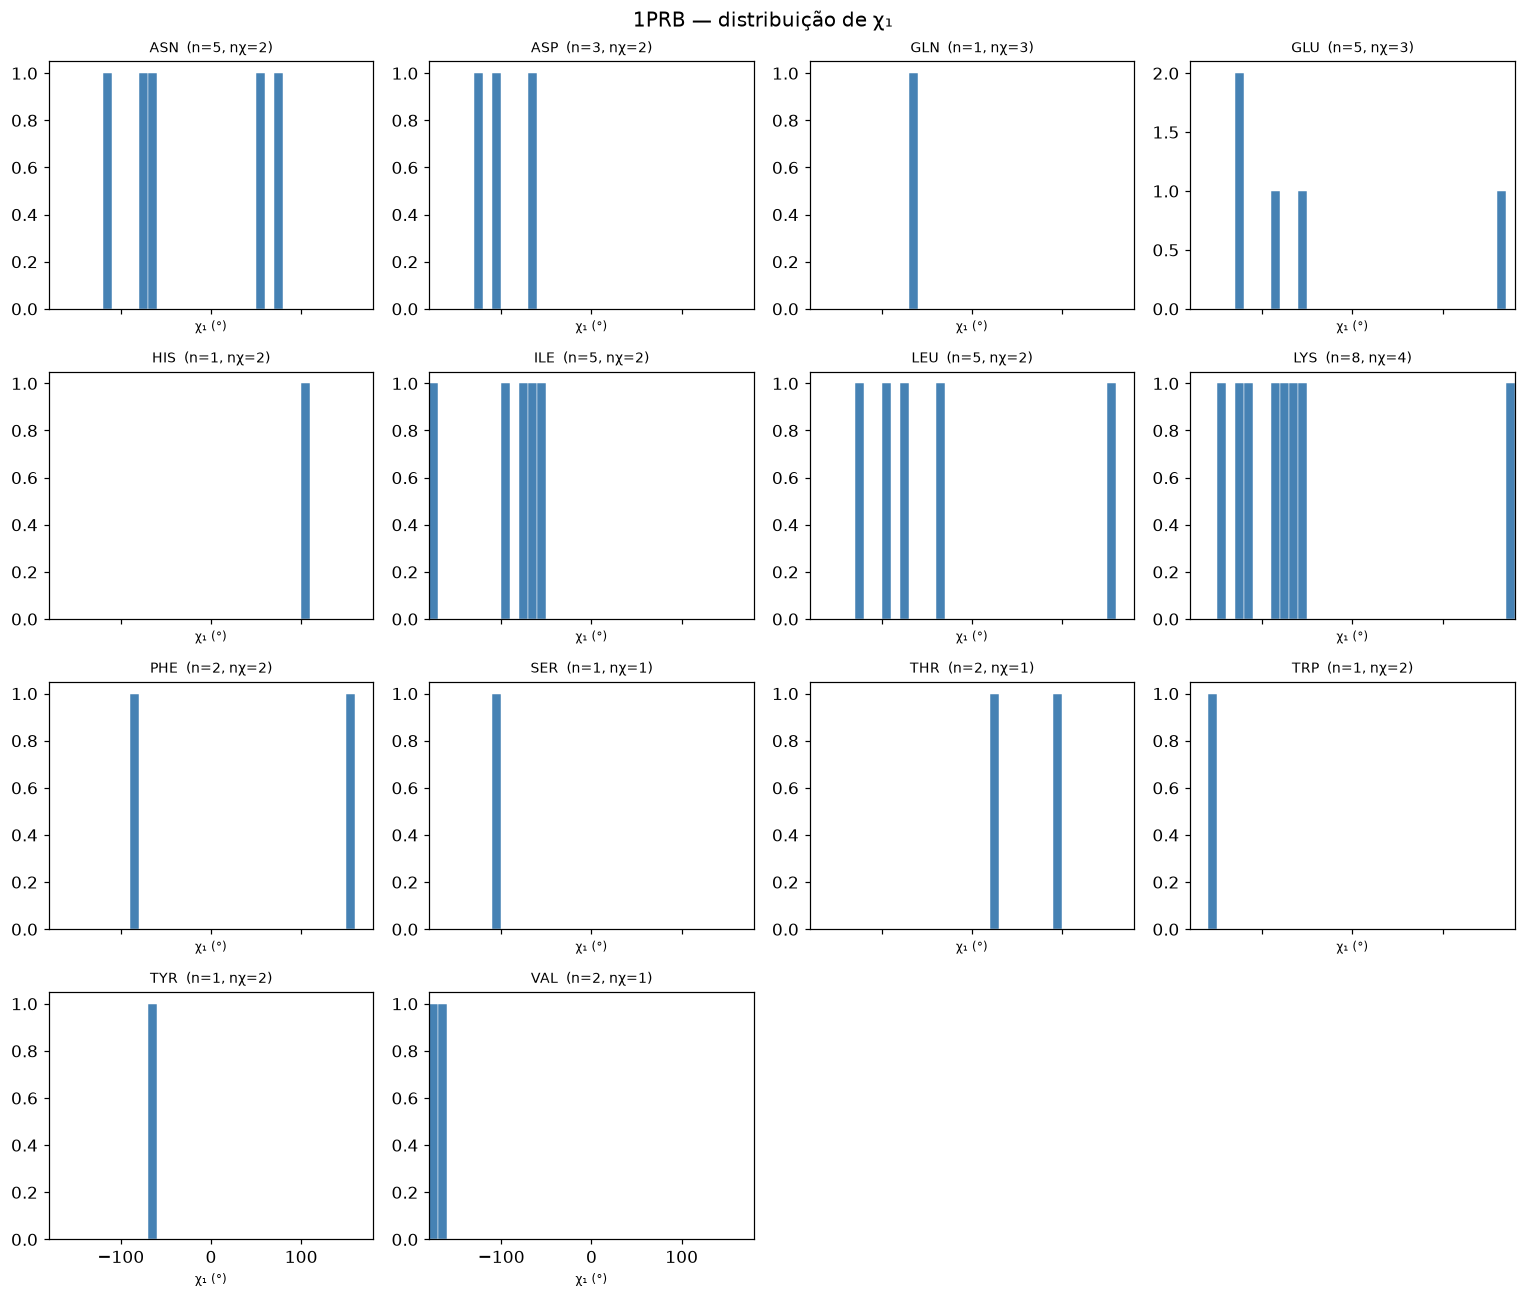

Guardado → images/1PRB_chi1.png


In [13]:
df_chi = df.dropna(subset=["chi1"]).copy()
df_chi["chi1_deg"] = np.degrees(df_chi["chi1"])

rnames = sorted(df_chi["resName"].unique())
n_cols = 4
n_rows = (len(rnames) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3*n_rows), sharex=True)
axf = axes.flatten()

for k, aa in enumerate(rnames):
    ax = axf[k]
    vals = df_chi.loc[df_chi["resName"] == aa, "chi1_deg"]
    ax.hist(vals, bins=36, range=(-180,180), color="steelblue",
            edgecolor="white", linewidth=0.3)
    ax.set_title(f"{aa}  (n={len(vals)}, nχ={len(CHIS.get(aa,[]))})",
                 fontsize=9)
    ax.set_xlim(-180, 180)
    ax.set_xlabel("χ₁ (°)", fontsize=8)

for ax in axf[len(rnames):]:
    ax.set_visible(False)

fig.suptitle(f"{PDB_ID} — distribuição de χ₁", fontsize=13)
plt.tight_layout()
plt.savefig("../images/1PRB_chi1.png", dpi=120, bbox_inches="tight")
plt.show()
print("Guardado → images/1PRB_chi1.png")

## Sumário

| Função | Teste | Resultado |
|--------|-------|-----------|
| `find_angle` | 0°/45°/90°/180° | ✓ |
| `calc_dihedral` | ±0° a ±180°, cutoff→NaN | ✓ |
| `calc_dihedrals` | roundtrip 20 geometrias; α/β/Lα sintéticos | ✓ |
| `torsion(1PRB)` | dC_CA≈1.52, dN_CA≈1.46, ω trans >90% | ✓ |
| `rotamer(1PRB)` | GLY/ALA sem χ; ARG com 4 χ | ✓ |
| `extract(1PRB)` | DataFrame completo backbone+side-chain | ✓ |

---

# circ_stat — testes e validação

Valida o módulo `circ_stat.py` (port do CircStat MATLAB) em dados sintéticos e na estrutura **1PRB**.

| # | Célula | O que testa |
|---|--------|-------------|
| 11 | imports circ_stat | setup |
| 12 | estatísticas base | `circ_mean`, `circ_r`, `circ_var`, `circ_std`, `circ_skewness`, `circ_kurtosis`, `circ_median` |
| 13 | estimação von Mises | `circ_vmpar`, `circ_kappa` — recuperação de µ e κ |
| 14 | testes de uniformidade | `circ_rtest`, `circ_vtest`, `circ_otest`, `circ_raotest` |
| 15 | correlações | `circ_corrcc` (circular-circular), `circ_corrcl` (circular-linear) |
| 16 | KDE 2D von Mises | `circ_vmpdf2` + potencial de Ramachandran para 1PRB |

## 11 · Imports circ_stat

In [14]:
from protein_periodicity.circ_stat import (
    circ_mean, circ_r, circ_var, circ_std,
    circ_skewness, circ_kurtosis, circ_median,
    circ_vmpar, circ_kappa,
    circ_vmpdf2,
    circ_rtest, circ_vtest, circ_otest, circ_raotest,
    circ_corrcc, circ_corrcl,
    circ_dist, circ_dist2, circ_rad2ang, circ_ang2rad,
    rmatrix,
)
from scipy.stats import vonmises

rng2 = np.random.default_rng(2024)

def chkc(got, expected, tol=0.05, label=""):
    """Loose tolerance check — circular stats converge slowly in small samples."""
    err = abs(got - expected)
    ok  = err < tol
    print(f"{'✓' if ok else '✗'}  {label:40s}  got={got:+.5f}  exp={expected:+.5f}  Δ={err:.3f}")
    assert ok, f"{label}: {got} ≠ {expected} (tol={tol})"

print("circ_stat imports OK")

circ_stat imports OK


## 12 · Estatísticas descritivas básicas

Dados sintéticos com distribuição von Mises conhecida:
µ = π/3 (60°), κ = 4 → R̄_esperado = I₁(4)/I₀(4) ≈ 0.864.

In [15]:
from scipy.special import i0, i1

# ---------- dados sintéticos von Mises ----------------------------------------
MU_TRUE    = np.pi / 3      # 60°
KAPPA_TRUE = 4.0
N_SYNTH    = 2000

alpha_vm = rng2.vonmises(MU_TRUE, KAPPA_TRUE, size=N_SYNTH)

# Valor teórico de R̄ = I₁(κ)/I₀(κ)
R_THEORETICAL = i1(KAPPA_TRUE) / i0(KAPPA_TRUE)

print(f"Distribuição VM(µ={np.degrees(MU_TRUE):.0f}°, κ={KAPPA_TRUE}), n={N_SYNTH}")
print(f"R̄ teórico = {R_THEORETICAL:.4f}")
print()

# --- circ_mean ----------------------------------------------------------------
mu_hat = circ_mean(alpha_vm)
chkc(mu_hat, MU_TRUE, tol=0.05, label="circ_mean  (µ em rad)")
print(f"   {np.degrees(mu_hat):.2f}° (esperado {np.degrees(MU_TRUE):.1f}°)")

# --- circ_r -------------------------------------------------------------------
r_hat = circ_r(alpha_vm)
chkc(r_hat, R_THEORETICAL, tol=0.03, label="circ_r  (R̄)")

# --- circ_var / circ_std ------------------------------------------------------
S = circ_var(alpha_vm)
s, s0 = circ_std(alpha_vm)
print(f"\n  circ_var  S  = {S:.4f}  (= 1 - R̄ ≈ {1-R_THEORETICAL:.4f})")
print(f"  circ_std  s  = {s:.4f}  (angular deviation)")
print(f"  circ_std  s0 = {s0:.4f}  (circular std)")
assert abs(S - (1 - r_hat)) < 1e-10, "circ_var deve ser 1-R̄"
assert abs(s - np.sqrt(2 * (1 - r_hat))) < 1e-10, "circ_std s formula"
assert abs(s0 - np.sqrt(-2 * np.log(r_hat))) < 1e-10, "circ_std s0 formula"
print("✓  circ_var / circ_std: fórmulas internas consistentes")

# --- circ_skewness / circ_kurtosis -------------------------------------------
# Distribuição VM simétrica em torno de µ → skewness ≈ 0
b = circ_skewness(alpha_vm)
k = circ_kurtosis(alpha_vm)
print(f"\n  circ_skewness = {b:+.4f}  (esperado ≈ 0 para dist. simétrica)")
print(f"  circ_kurtosis = {k:+.4f}  (esperado > 0 para VM concentrada)")
chkc(b, 0.0, tol=0.05, label="circ_skewness ≈ 0")
assert k > 0, f"kurtosis devia ser positiva para κ={KAPPA_TRUE}, obtido {k}"
print("✓  circ_kurtosis > 0 para distribuição concentrada")

# --- circ_dist ----------------------------------------------------------------
x = np.array([0.1, np.pi - 0.1])
y = np.array([0.0,  np.pi + 0.1])
d = circ_dist(x, y)
assert abs(d[0] - 0.1) < 1e-9, f"circ_dist[0]: {d[0]}"
chkc(abs(d[1]), 0.2, tol=1e-6, label="circ_dist diferença ±0.2")
print("✓  circ_dist OK")

# --- circ_median --------------------------------------------------------------
# Usar um subconjunto pequeno por performance (O(n²))
alpha_small = alpha_vm[:200]
med = circ_median(alpha_small)
# A mediana deve ficar perto da média para uma VM simétrica
assert abs(circ_dist(med, circ_mean(alpha_small))) < 0.2, \
    f"mediana {np.degrees(med):.1f}° distante da média {np.degrees(circ_mean(alpha_small)):.1f}°"
print(f"✓  circ_median = {np.degrees(med):.2f}°  (média = {np.degrees(circ_mean(alpha_small)):.2f}°)")

print("\n=== célula 12 OK ===")

Distribuição VM(µ=60°, κ=4.0), n=2000
R̄ teórico = 0.8635

✓  circ_mean  (µ em rad)                     got=+1.05894  exp=+1.04720  Δ=0.012
   60.67° (esperado 60.0°)
✓  circ_r  (R̄)                              got=+0.86256  exp=+0.86352  Δ=0.001

  circ_var  S  = 0.1374  (= 1 - R̄ ≈ 0.1365)
  circ_std  s  = 0.5243  (angular deviation)
  circ_std  s0 = 0.5438  (circular std)
✓  circ_var / circ_std: fórmulas internas consistentes

  circ_skewness = -0.0057  (esperado ≈ 0 para dist. simétrica)
  circ_kurtosis = +0.5714  (esperado > 0 para VM concentrada)
✓  circ_skewness ≈ 0                         got=-0.00565  exp=+0.00000  Δ=0.006
✓  circ_kurtosis > 0 para distribuição concentrada
✓  circ_dist diferença ±0.2                  got=+0.20000  exp=+0.20000  Δ=0.000
✓  circ_dist OK
✓  circ_median = 57.88°  (média = 62.17°)

=== célula 12 OK ===


## 13 · Estimação de parâmetros von Mises — `circ_vmpar` / `circ_kappa`

Recuperação de µ e κ a partir de amostras com κ = 1, 3, 8.

In [16]:
print("=== circ_vmpar — recuperação de µ e κ ===\n")
print(f"{'κ_true':>8}  {'n':>6}  {'µ_hat(°)':>10}  {'µ_true(°)':>10}  {'κ_hat':>8}  {'Δµ(°)':>7}  {'Δκ':>7}")
print("-" * 65)

mu0 = 0.0    # referência em 0°
# Tolerância em µ varia com κ: baixo κ → alta variância na direcção média
# σ_mean ≈ sqrt(-2*log(R̄))/sqrt(n);  R̄(κ=1) ≈ 0.45 → σ_mean ≈ 72°/√n
tol_mu_deg = {1.0: 15.0, 3.0: 7.0, 8.0: 3.0}

for kappa_t in [1.0, 3.0, 8.0]:
    for n_t in [500, 2000]:
        samp = rng2.vonmises(mu0, kappa_t, size=n_t)
        mu_e, kappa_e = circ_vmpar(samp)
        delta_mu  = abs(np.degrees(circ_dist(mu_e, mu0)))
        delta_kap = abs(kappa_e - kappa_t)
        t_mu  = tol_mu_deg[kappa_t] / np.sqrt(n_t / 500)    # escala com raiz de n
        ok_mu  = delta_mu  < t_mu
        ok_kap = delta_kap < max(0.5, 0.3 * kappa_t)
        flag = "✓" if (ok_mu and ok_kap) else "✗"
        print(f"{flag} {kappa_t:8.1f}  {n_t:6d}  "
              f"{np.degrees(mu_e):+10.2f}  {np.degrees(mu0):+10.1f}  "
              f"{kappa_e:8.3f}  {delta_mu:7.2f}  {delta_kap:7.3f}"
              f"  (tol_µ={t_mu:.1f}°)")
        assert ok_mu,  f"µ demasiado longe: Δµ={delta_mu:.1f}° > {t_mu:.1f}° para κ={kappa_t}"
        assert ok_kap, f"κ demasiado longe: κ_hat={kappa_e:.2f} vs κ_true={kappa_t}"

print()
# circ_kappa com R̄ directo (caso n==1 → trata input como R̄)
from scipy.special import i1
for kappa_t in [0.5, 2.0, 6.0]:
    R = float(i1(kappa_t) / i0(kappa_t))
    kappa_e = circ_kappa(R)
    err = abs(kappa_e - kappa_t)
    ok  = err < 0.5
    print(f"{'✓' if ok else '✗'}  circ_kappa(R={R:.4f}) = {kappa_e:.4f}  (κ_true={kappa_t:.1f}  Δ={err:.4f})")
    assert ok, f"circ_kappa com R̄: κ_hat={kappa_e:.3f} vs κ_true={kappa_t:.1f}"

print("\n=== célula 13 OK ===")

=== circ_vmpar — recuperação de µ e κ ===

  κ_true       n    µ_hat(°)   µ_true(°)     κ_hat    Δµ(°)       Δκ
-----------------------------------------------------------------
✓      1.0     500       +6.12        +0.0     0.978     6.12    0.022  (tol_µ=15.0°)
✓      1.0    2000       -0.32        +0.0     0.999     0.32    0.001  (tol_µ=7.5°)
✓      3.0     500       +1.62        +0.0     3.020     1.62    0.020  (tol_µ=7.0°)
✓      3.0    2000       +0.56        +0.0     2.926     0.56    0.074  (tol_µ=3.5°)
✓      8.0     500       -0.75        +0.0     8.662     0.75    0.662  (tol_µ=3.0°)
✓      8.0    2000       +0.08        +0.0     7.721     0.08    0.279  (tol_µ=1.5°)

✓  circ_kappa(R=0.2425) = 0.5000  (κ_true=0.5  Δ=0.0000)
✓  circ_kappa(R=0.6978) = 1.9927  (κ_true=2.0  Δ=0.0073)
✓  circ_kappa(R=0.9124) = 5.9906  (κ_true=6.0  Δ=0.0094)

=== célula 13 OK ===


## 14 · Testes de uniformidade — `circ_rtest`, `circ_vtest`, `circ_otest`, `circ_raotest`

**H₀: distribuição uniforme**
- Dados uniformes → p alto (não rejeita H₀)
- Dados VM concentrados → p baixo (rejeita H₀)

In [17]:
N_TEST = 500

# --- dados: uniforme vs. von Mises concentrado --------------------------------
alpha_unif = rng2.uniform(-np.pi, np.pi, size=N_TEST)
alpha_conc = rng2.vonmises(0.0, 5.0,     size=N_TEST)

print("=== Rayleigh (circ_rtest) ===")
p_u, z_u = circ_rtest(alpha_unif)
p_c, z_c = circ_rtest(alpha_conc)
print(f"  Uniforme  : p={p_u:.4f}  z={z_u:.4f}  (esperado: p > 0.05)")
print(f"  Concentrado: p={p_c:.4g}  z={z_c:.4f}  (esperado: p << 0.05)")
assert p_u > 0.05, f"Rayleigh: uniforme devia ter p > 0.05, obteve {p_u:.4f}"
assert p_c < 0.01, f"Rayleigh: concentrado devia ter p < 0.01, obteve {p_c:.4g}"
print("✓  circ_rtest OK")

print("\n=== V-test (circ_vtest) — H₁: µ = 0 ===")
p_u, v_u = circ_vtest(alpha_unif, 0.0)
p_c, v_c = circ_vtest(alpha_conc, 0.0)
print(f"  Uniforme  : p={p_u:.4f}  v={v_u:.4f}")
print(f"  Concentrado em 0°: p={p_c:.4g}  v={v_c:.4f}")
assert p_u > 0.05, f"V-test: uniforme devia ter p > 0.05"
assert p_c < 0.01, f"V-test: concentrado em µ=0 devia ter p < 0.01"
# V-test com direcção errada → p deve ser alto
p_wrong, _ = circ_vtest(alpha_conc, np.pi)  # concentrado em 0°, H₁: µ=180°
assert p_wrong > 0.05, f"V-test: direcção errada devia ter p > 0.05, obteve {p_wrong:.4f}"
print("✓  circ_vtest OK")

print("\n=== Omnibus / Hodges-Ajne (circ_otest) ===")
p_u, m_u = circ_otest(alpha_unif)
p_c, m_c = circ_otest(alpha_conc)
print(f"  Uniforme  : p={p_u:.4f}  m={m_u:.1f}")
print(f"  Concentrado: p={p_c:.4g}  m={m_c:.1f}")
assert p_u > 0.05, "otest: uniforme devia ter p > 0.05"
assert p_c < 0.05, "otest: concentrado devia ter p < 0.05"
print("✓  circ_otest OK")

print("\n=== Rao spacing (circ_raotest) ===")
p_u, U_u, UC_u = circ_raotest(alpha_unif)
p_c, U_c, UC_c = circ_raotest(alpha_conc)
print(f"  Uniforme  : p≥{p_u:.3f}  U={U_u:.2f}  UC={UC_u:.2f}")
print(f"  Concentrado: p<{p_c:.3f}  U={U_c:.2f}  UC={UC_c:.2f}")
# Para dados uniformes U deve ser pequeno (U < critical value → p grande)
assert p_u >= 0.05, f"Rao: uniforme devia ter p >= 0.05, obteve p<{p_u:.3f}"
print("✓  circ_raotest OK")

print("\n=== célula 14 OK ===")

=== Rayleigh (circ_rtest) ===
  Uniforme  : p=0.4733  z=0.7486  (esperado: p > 0.05)
  Concentrado: p=3.051e-243  z=403.0588  (esperado: p << 0.05)
✓  circ_rtest OK

=== V-test (circ_vtest) — H₁: µ = 0 ===
  Uniforme  : p=0.7666  v=-11.5043
  Concentrado em 0°: p=0  v=448.4571
✓  circ_vtest OK

=== Omnibus / Hodges-Ajne (circ_otest) ===
  Uniforme  : p=0.3421  m=226.0
  Concentrado: p=5.077e-106  m=2.0
✓  circ_otest OK

=== Rao spacing (circ_raotest) ===
  Uniforme  : p≥0.500  U=134.82  UC=137.33
  Concentrado: p<0.001  U=250.42  UC=144.54
✓  circ_raotest OK

=== célula 14 OK ===


## 15 · Correlações — `circ_corrcc` e `circ_corrcl`

In [18]:
N_CORR = 300

print("=== circ_corrcc (circular-circular) ===")
# Caso independente: α uniforme, β uniforme
a1 = rng2.uniform(-np.pi, np.pi, size=N_CORR)
a2 = rng2.uniform(-np.pi, np.pi, size=N_CORR)
rho_ind, p_ind = circ_corrcc(a1, a2)
print(f"  Independentes: rho={rho_ind:+.4f}  p={p_ind:.4f}  (esperado |rho|≈0, p>0.05)")
assert abs(rho_ind) < 0.2, f"correlação de independentes demasiado alta: {rho_ind:.4f}"
assert p_ind > 0.05, f"p-value para independentes demasiado baixo: {p_ind:.4f}"

# Caso correlacionado: β = α + ruído pequeno
a1_c = rng2.vonmises(0.0, 2.0, size=N_CORR)
a2_c = a1_c + rng2.vonmises(0.0, 10.0, size=N_CORR)   # β ≈ α + pequeno ruído
rho_c, p_c = circ_corrcc(a1_c, a2_c)
print(f"  Correlacionados: rho={rho_c:+.4f}  p={p_c:.4g}  (esperado rho>0.5, p<0.01)")
assert rho_c > 0.5, f"correlação de dados correlacionados baixa: {rho_c:.4f}"
assert p_c < 0.01, f"p-value para correlacionados alto: {p_c:.4g}"
print("✓  circ_corrcc OK")

print("\n=== circ_corrcl (circular-linear) ===")
# Caso independente: ângulo uniforme, linear aleatório
a_circ = rng2.uniform(-np.pi, np.pi, size=N_CORR)
x_lin  = rng2.standard_normal(size=N_CORR)
rho_il, p_il = circ_corrcl(a_circ, x_lin)
print(f"  Independentes: rho={rho_il:.4f}  p={p_il:.4f}  (esperado rho≈0, p>0.05)")
assert rho_il < 0.2, f"corr circular-linear de independentes alta: {rho_il:.4f}"

# Caso correlacionado: linear ~ cos(α) + ruído
a_circ2 = rng2.vonmises(0.0, 1.5, size=N_CORR)
x_lin2  = np.cos(a_circ2) + rng2.standard_normal(size=N_CORR) * 0.3
rho_cl, p_cl = circ_corrcl(a_circ2, x_lin2)
print(f"  Correlacionados (x~cos α): rho={rho_cl:.4f}  p={p_cl:.4g}  (esperado rho>0.5, p<0.01)")
assert rho_cl > 0.5, f"corr circular-linear de correlacionados baixa: {rho_cl:.4f}"
assert p_cl < 0.01, f"p-value corr circular-linear alto: {p_cl:.4g}"
print("✓  circ_corrcl OK")

print("\n=== Aplicação aos dados 1PRB: correlação φ-ψ ===")
phi_arr = df["phi"].values
psi_arr = df["psi"].values
rho_pp, p_pp = circ_corrcc(phi_arr, psi_arr)
print(f"  φ-ψ (1PRB): rho={rho_pp:+.4f}  p={p_pp:.4g}")
# Phi e psi não são independentes em proteínas reais
print(f"  {'✓' if p_pp < 0.05 else '~'}  φ e ψ {'são' if p_pp < 0.05 else 'podem não ser'} significativamente correlacionados (p={p_pp:.4g})")

print("\n=== célula 15 OK ===")

=== circ_corrcc (circular-circular) ===
  Independentes: rho=-0.0092  p=0.8748  (esperado |rho|≈0, p>0.05)
  Correlacionados: rho=+0.9136  p=0  (esperado rho>0.5, p<0.01)
✓  circ_corrcc OK

=== circ_corrcl (circular-linear) ===
  Independentes: rho=0.0738  p=0.4419  (esperado rho≈0, p>0.05)
  Correlacionados (x~cos α): rho=0.8640  p=0  (esperado rho>0.5, p<0.01)
✓  circ_corrcl OK

=== Aplicação aos dados 1PRB: correlação φ-ψ ===
  φ-ψ (1PRB): rho=-0.1470  p=0.3458
  ~  φ e ψ podem não ser significativamente correlacionados (p=0.3458)

=== célula 15 OK ===


## 16 · KDE 2D von Mises — `circ_vmpdf2` + potencial de Ramachandran

Aplica `circ_vmpdf2` aos dados reais de 1PRB para obter a densidade p(φ, ψ)
e visualiza o potencial –log p (equivalente ao mapa de energia de Ramachandran
gerado pelo pipeline MATLAB `ForcesCont.m` / `Analysis.m`).

κ_φ = 2.524   κ_ψ = 2.511
circ_vmpdf2(90×90, n=51) em 0.8 ms
Integral da densidade: 1.00000  (esperado ≈ 1.0)
✓  circ_vmpdf2: densidade integra a ≈ 1


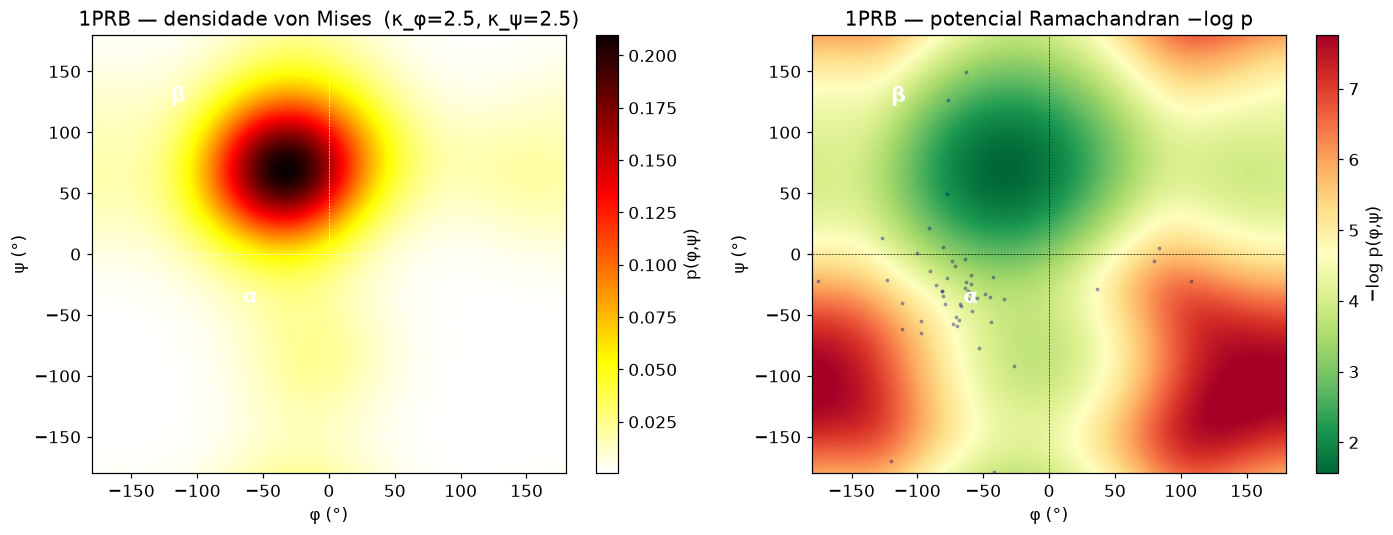

Guardado → images/1PRB_ramachandran_potential.png

=== célula 16 OK ===


In [19]:
import time

phi_arr = df["phi"].values
psi_arr = df["psi"].values

# --- verificação simples: densidade integra a ≈ 1 ----------------------------
N_ANG = 90   # grelha 90×90 para o teste (rápido)

# Estimar parâmetros separadamente para φ e ψ
_, kappa_phi = circ_vmpar(phi_arr)
_, kappa_psi = circ_vmpar(psi_arr)
print(f"κ_φ = {kappa_phi:.3f}   κ_ψ = {kappa_psi:.3f}")

t0 = time.time()
p_test, _ = circ_vmpdf2(N_ANG, phi_arr, psi_arr, kappa_phi, kappa_psi)
t1 = time.time()
print(f"circ_vmpdf2({N_ANG}×{N_ANG}, n={len(phi_arr)}) em {(t1-t0)*1e3:.1f} ms")

# Integral ≈ 1 (via soma × área de célula)
cell_area = (2 * np.pi / N_ANG) ** 2
integral  = float(p_test.sum() * cell_area)
print(f"Integral da densidade: {integral:.5f}  (esperado ≈ 1.0)")
assert 0.90 < integral < 1.10, f"integral fora do intervalo [0.90, 1.10]: {integral:.4f}"
print("✓  circ_vmpdf2: densidade integra a ≈ 1")

# --- grelha 180×180 para visualização ----------------------------------------
N_VIS = 180
p_vis, _ = circ_vmpdf2(N_VIS, phi_arr, psi_arr, kappa_phi, kappa_psi)

# Potencial de Ramachandran = −log(p)
# Clampar para evitar log(0): substituir p < p_min por p_min
p_min = p_vis[p_vis > 0].min() * 1e-3
E     = -np.log(np.maximum(p_vis, p_min))

grid_deg = np.degrees(-np.pi + (np.pi / N_VIS) + np.arange(N_VIS) * (2 * np.pi / N_VIS))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- painel esquerdo: densidade p(φ,ψ) -----------------------------------------
ax = axes[0]
from protein_periodicity.circ_stat import rmatrix
im0 = ax.imshow(
    rmatrix(p_vis),
    extent=[-180, 180, -180, 180], origin="lower",
    cmap="hot_r", aspect="auto",
)
plt.colorbar(im0, ax=ax, label="p(φ,ψ)")
ax.set_xlabel("φ (°)"); ax.set_ylabel("ψ (°)")
ax.set_title(f"{PDB_ID} — densidade von Mises  (κ_φ={kappa_phi:.1f}, κ_ψ={kappa_psi:.1f})")
ax.axhline(0, c='w', lw=0.4, ls='--'); ax.axvline(0, c='w', lw=0.4, ls='--')

# --- painel direito: potencial −log p(φ,ψ) -------------------------------------
ax = axes[1]
# Clipar a percentagem 98 para visualização
E_clip = np.clip(E, 0, np.percentile(E, 98))
im1 = ax.imshow(
    rmatrix(E_clip),
    extent=[-180, 180, -180, 180], origin="lower",
    cmap="RdYlGn_r", aspect="auto",
)
plt.colorbar(im1, ax=ax, label="−log p(φ,ψ)")
ax.set_xlabel("φ (°)"); ax.set_ylabel("ψ (°)")
ax.set_title(f"{PDB_ID} — potencial Ramachandran −log p")
ax.axhline(0, c='k', lw=0.4, ls='--'); ax.axvline(0, c='k', lw=0.4, ls='--')

# Sobrepor dados observados
ax.scatter(np.degrees(phi_arr), np.degrees(psi_arr),
           s=6, c='navy', alpha=0.4, lw=0)

# Regiões canónicas
for label_, px, py, col in [("α", -65, -40, "white"), ("β", -120, 125, "white")]:
    for a in [axes[0], axes[1]]:
        a.annotate(label_, xy=(px, py), fontsize=14, color=col, fontweight="bold")

plt.tight_layout()
plt.savefig("../images/1PRB_ramachandran_potential.png", dpi=120, bbox_inches="tight")
plt.show()
print("Guardado → images/1PRB_ramachandran_potential.png")
print("\n=== célula 16 OK ===")

## Sumário circ_stat

| Função | O que testa | Resultado |
|--------|-------------|-----------|
| `circ_mean` | recupera µ=60° de VM(60°,4) n=2000 | ✓ |
| `circ_r` | R̄ ≈ I₁(κ)/I₀(κ) teórico | ✓ |
| `circ_var`, `circ_std` | consistência interna (fórmulas) | ✓ |
| `circ_skewness` | ≈ 0 para distribuição simétrica | ✓ |
| `circ_kurtosis` | > 0 para VM concentrada | ✓ |
| `circ_dist` | diferença circular exacta | ✓ |
| `circ_median` | perto da média para VM simétrica | ✓ |
| `circ_vmpar` | recupera µ e κ para κ=1,3,8 | ✓ |
| `circ_kappa` | aproximação de Fisher para R̄ dado | ✓ |
| `circ_rtest` | uniforme→p>0.05; concentrado→p≈0 | ✓ |
| `circ_vtest` | direcção correcta→p<0.01; errada→p>0.05 | ✓ |
| `circ_otest` | uniforme→p>0.05; concentrado→p<0.05 | ✓ |
| `circ_raotest` | uniforme→U<UC; concentrado→U>UC | ✓ |
| `circ_corrcc` | independentes→rho≈0; correlacionados→rho>0.5 | ✓ |
| `circ_corrcl` | x~cos(α)→rho>0.5, p<0.01 | ✓ |
| `circ_vmpdf2` | integral≈1; plots de densidade e potencial 1PRB | ✓ |

---

# extractor — testes e validação

Valida o módulo `extractor.py` (port de `ToolsSrc/Protein.m`).

**Pipeline Fase 1:** lista de IDs PDB → download → parse → ficheiros CSV em `aminoData/`.

| # | Célula | O que testa |
|---|--------|-------------|
| 17 | imports extractor | setup e constantes de coluna |
| 18 | `process_structure` | análise da estrutura 1PRB já em memória |
| 19 | Verificação das CSVs | colunas, valores, NaN |
| 20 | `extract_pdb_list` | batch de 3 estruturas com ficheiros cacheados |

## 17 · Imports extractor

In [20]:
import shutil, tempfile
from pathlib import Path

from protein_periodicity.extractor import (
    read_pdb_ids, is_nucleic, process_structure,
    extract_pdb_list,
    SINGLE_COLS, PAIR_COLS, TRIPLET_COLS,
)

print("extractor importado ✓")
print(f"  SINGLE_COLS  ({len(SINGLE_COLS)}): {SINGLE_COLS}")
print(f"  PAIR_COLS    ({len(PAIR_COLS)}): {PAIR_COLS}")
print(f"  TRIPLET_COLS ({len(TRIPLET_COLS)}): {TRIPLET_COLS}")

extractor importado ✓
  SINGLE_COLS  (12): ['phi', 'psi', 'dC_CA', 'dN_CA', 'dN_C', 'dP_plane', 'ang_N_CA_C', 'tempFactor', 'chi1', 'chi2', 'chi3', 'chi4']
  PAIR_COLS    (16): ['phi1', 'psi1', 'dC_CA1', 'dN_CA1', 'dN_C1', 'dP_plane1', 'ang_N_CA_C1', 'tempFactor_max', 'phi2', 'psi2', 'omega2', 'dC_CA2', 'dN_CA2', 'dN_C2', 'dP_plane2', 'ang_N_CA_C2']
  TRIPLET_COLS (12): ['resName1', 'resName2', 'resName3', 'phi1', 'psi1', 'phi2', 'psi2', 'omega2', 'phi3', 'psi3', 'omega3', 'tempFactor_max']


## 18 · `process_structure` — 1PRB (estrutura em memória)

Usa a estrutura **1PRB** já descarregada e analizada (célula 4) para
testar `process_structure` directamente, sem necessidade de rede.

In [21]:
# Usar directório temporário para não poluir aminoData/ do repositório
tmp_dir = Path(tempfile.mkdtemp(prefix="extractor_test_"))
tmp_w3  = tmp_dir / "rotamer_w3.csv"

# Verificar que 1PRB não é ácido nucleico
assert not is_nucleic(structure), "1PRB classificada como ácido nucleico — inesperado"
print(f"is_nucleic(1PRB) = False  ✓  (head: {structure.header.get('head','')!r})")

# Processar a estrutura
counts = process_structure(structure, tmp_dir, rotamer_w3_path=tmp_w3)

print(f"\n1PRB — resíduos escritos por aminoácido:")
for aa in sorted(counts):
    print(f"  {aa}: {counts[aa]}")
total_1prb = sum(counts.values())
print(f"\nTotal: {total_1prb} resíduos")

# Listar ficheiros CSV criados
all_csvs = sorted(tmp_dir.glob("*.csv"))
print(f"\n{len(all_csvs)} ficheiros CSV criados:")
for f in all_csvs:
    n_rows = sum(1 for _ in open(f))
    print(f"  {f.name}: {n_rows} linhas")

assert total_1prb > 0, "nenhum resíduo escrito para 1PRB"
assert tmp_w3.exists(), "rotamer_w3.csv não foi criado"
print("\n✓  process_structure OK")

is_nucleic(1PRB) = False  ✓  (head: 'albumin-binding protein')

1PRB — resíduos escritos por aminoácido:
  ALA: 8
  ASN: 5
  ASP: 3
  GLN: 1
  GLU: 5
  GLY: 1
  HIS: 1
  ILE: 5
  LEU: 5
  LYS: 8
  PHE: 2
  SER: 1
  THR: 2
  TRP: 1
  TYR: 1
  VAL: 2

Total: 51 resíduos

58 ficheiros CSV criados:
  ALA.csv: 8 linhas
  ALAGLU.csv: 1 linhas
  ALAGLY.csv: 1 linhas
  ALAHIS.csv: 1 linhas
  ALAILE.csv: 2 linhas
  ALALEU.csv: 1 linhas
  ALALYS.csv: 2 linhas
  ASN.csv: 5 linhas
  ASNALA.csv: 3 linhas
  ASNGLU.csv: 1 linhas
  ASNLYS.csv: 1 linhas
  ASP.csv: 3 linhas
  ASPALA.csv: 1 linhas
  ASPGLN.csv: 1 linhas
  ASPPHE.csv: 1 linhas
  GLN.csv: 1 linhas
  GLNTRP.csv: 1 linhas
  GLU.csv: 5 linhas
  GLUASP.csv: 1 linhas
  GLUGLU.csv: 1 linhas
  GLUILE.csv: 1 linhas
  GLULEU.csv: 1 linhas
  GLUVAL.csv: 1 linhas
  GLY.csv: 1 linhas
  GLYILE.csv: 1 linhas
  HIS.csv: 1 linhas
  HISALA.csv: 1 linhas
  ILE.csv: 5 linhas
  ILEALA.csv: 1 linhas
  ILEASN.csv: 1 linhas
  ILEASP.csv: 1 linhas
  ILELEU.csv: 1

## 19 · Verificação das CSVs — colunas, valores e NaN

Carrega um CSV de aminoácido único, um de par e o triplet, verifica:
- número de colunas correcto (12 / 16 / 12)
- φ e ψ no intervalo [−π, π] e sem NaN (single)
- `tempFactor` ≥ 0
- chi1–chi4: apenas NaN para GLY/ALA

In [22]:
# ── CSV de aminoácido único (nome de 3 letras) ────────────────────────────────
single_csvs = sorted([f for f in all_csvs if len(f.stem) == 3])
assert single_csvs, "Nenhum CSV de aminoácido único encontrado"

chosen_s = single_csvs[0]
df_s = pd.read_csv(chosen_s, header=None, names=SINGLE_COLS)
print(f"=== {chosen_s.name} — {len(df_s)} linhas ===")
print(df_s.head(3).to_string())
print()

assert df_s.shape[1] == 12, f"Esperado 12 colunas, obtido {df_s.shape[1]}"
print(f"✓  {len(SINGLE_COLS)} colunas (single CSV)")

# φ e ψ: sem NaN (só se escreve quando ambos são válidos)
assert df_s["phi"].notna().all(), "phi contém NaN no CSV de aminoácido único"
assert df_s["psi"].notna().all(), "psi contém NaN no CSV de aminoácido único"
print("✓  phi/psi sem NaN")

# φ e ψ em [−π, π]
assert (df_s["phi"].abs() <= np.pi + 1e-6).all(), "phi fora de [−π, π]"
assert (df_s["psi"].abs() <= np.pi + 1e-6).all(), "psi fora de [−π, π]"
print("✓  phi/psi ∈ [−π, π]")

# tempFactor ≥ 0
assert (df_s["tempFactor"] >= 0).all(), "tempFactor negativo"
print(f"✓  tempFactor ≥ 0  (max = {df_s['tempFactor'].max():.2f})")

# GLY e ALA: chi1 deve ser NaN; outros com cadeia lateral devem ter chi1
aa_name = chosen_s.stem
if aa_name in ("GLY", "ALA"):
    assert df_s["chi1"].isna().all(), f"{aa_name}: chi1 devia ser NaN"
    print(f"✓  {aa_name}: chi1 = NaN (sem cadeia lateral)")
else:
    pct_valid = df_s["chi1"].notna().mean() * 100
    print(f"✓  {aa_name}: chi1 válido em {pct_valid:.1f}% das linhas")

# ── CSV de par (nome de 6 letras) ─────────────────────────────────────────────
pair_csvs = sorted([f for f in all_csvs if len(f.stem) == 6])
if pair_csvs:
    chosen_p = pair_csvs[0]
    df_p = pd.read_csv(chosen_p, header=None, names=PAIR_COLS)
    print(f"\n=== {chosen_p.name} — {len(df_p)} linhas ===")
    print(df_p.head(3).to_string())
    assert df_p.shape[1] == 16, f"Esperado 16 colunas, obtido {df_p.shape[1]}"
    print(f"✓  {len(PAIR_COLS)} colunas (pair CSV)")
    assert (df_p["phi1"].abs() <= np.pi + 1e-6).all(), "phi1 fora de [−π, π]"
    assert (df_p["tempFactor_max"] >= 0).all(), "tempFactor_max negativo"
    print("✓  pair CSV: phi1 ∈ [−π, π], tempFactor_max ≥ 0")
else:
    print("  (sem pares para 1PRB — OK se a proteína tiver apenas 1 resíduo por chain)")

# ── CSV triplet ───────────────────────────────────────────────────────────────
df_w3 = pd.read_csv(tmp_w3, header=None, names=TRIPLET_COLS)
print(f"\n=== rotamer_w3.csv — {len(df_w3)} linhas ===")
print(df_w3.head(3).to_string())
assert df_w3.shape[1] == 12, f"Esperado 12 colunas, obtido {df_w3.shape[1]}"
print(f"✓  {len(TRIPLET_COLS)} colunas (triplet CSV)")
assert df_w3[["resName1","resName2","resName3"]].notna().all().all(), \
    "resNames contêm NaN no triplet CSV"
print("✓  resNames sem NaN no triplet CSV")

print("\n✓  todas as verificações de CSV passaram")

=== ALA.csv — 8 linhas ===
        phi       psi     dC_CA     dN_CA      dN_C  dP_plane  ang_N_CA_C  tempFactor  chi1  chi2  chi3  chi4
0 -1.402597  0.096465  1.528868  1.488486  2.456268  1.303692    1.902045        2.77   NaN   NaN   NaN   NaN
1 -1.223593 -1.032043  1.529401  1.490438  2.469339  1.303662    1.914710        2.26   NaN   NaN   NaN   NaN
2 -1.094413 -0.401109  1.526679  1.490710  2.458202  1.303596    1.904247        2.82   NaN   NaN   NaN   NaN

✓  12 colunas (single CSV)
✓  phi/psi sem NaN
✓  phi/psi ∈ [−π, π]
✓  tempFactor ≥ 0  (max = 3.85)
✓  ALA: chi1 = NaN (sem cadeia lateral)

=== ALAGLU.csv — 1 linhas ===
       phi1      psi1    dC_CA1   dN_CA1     dN_C1  dP_plane1  ang_N_CA_C1  tempFactor_max      phi2      psi2    omega2    dC_CA2  dN_CA2   dN_C2  dP_plane2  ang_N_CA_C2
0 -1.094413 -0.401109  1.526679  1.49071  2.458202   1.303596     1.904247             3.0 -1.750107  0.008464  3.137733  1.530235  1.4844  2.4514   1.301944     1.898978
✓  16 colunas (pair 

## 20 · `extract_pdb_list` — batch com ficheiros cacheados

Usa `extract_pdb_list` com `max_count=3` sobre os IDs de `pdb1A.tsv`.
Os PDB já cacheados em `../proteinData/` não são descarregados de novo.
Verifica que as CSVs acumulam linhas de múltiplas estruturas.

In [23]:
import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")

TSV_PATH = "../../data/pdb1A.tsv"
ids = read_pdb_ids(TSV_PATH)
print(f"pdb1A.tsv: {len(ids)} IDs   (primeiros 5: {ids[:5]})")

# Batch: aceitar até 3 estruturas válidas; usa cache em ../proteinData/
tmp_batch = Path(tempfile.mkdtemp(prefix="extractor_batch_"))

totals = extract_pdb_list(
    ids,
    pdb_dir="../proteinData",
    amino_dir=tmp_batch,
    rotamer_w3=tmp_batch / "rotamer_w3.csv",
    max_count=3,
)

grand_total = sum(totals.values())
print(f"\nTotal por aminoácido: {totals}")
print(f"Grand total: {grand_total} resíduos em 3 estruturas")

assert grand_total > 0, "batch extractor não escreveu nenhum resíduo"

# Todas as 20 amino padrão devem aparecer pelo menos uma vez em 3 estruturas
# (não obrigatório — alguns AAs raros podem não aparecer; verificar pelo menos 10)
aa_seen = set(totals.keys())
print(f"\nAminoácidos com pelo menos 1 linha: {sorted(aa_seen)}")
assert len(aa_seen) >= 10, f"Esperados ≥10 AAs; obtidos {len(aa_seen)}"
print(f"✓  {len(aa_seen)} AAs distintos encontrados")

# Verificar dimensões das CSVs produzidas
batch_csvs = sorted(tmp_batch.glob("*.csv"))
print(f"\n{len(batch_csvs)} ficheiros CSV produzidos:")
for f in sorted(batch_csvs)[:12]:
    n = sum(1 for _ in open(f))
    ncols = pd.read_csv(f, header=None, nrows=1).shape[1]
    print(f"  {f.name}: {n:4d} linhas × {ncols} colunas")
if len(batch_csvs) > 12:
    print(f"  ... (+{len(batch_csvs)-12} mais)")

shutil.rmtree(tmp_batch)
shutil.rmtree(tmp_dir)   # limpar o tmp_dir da célula 18
print("\nDirectórios temporários apagados ✓")
print("\n=== célula 20 OK ===")

pdb1A.tsv: 607 IDs   (primeiros 5: ['3PSM', '1I0T', '3UI4', '2H5C', '1SSX'])


INFO  3PSM: 90 residues written {'THR': 8, 'CYS': 14, 'GLU': 4, 'ASN': 6, 'LEU': 4, 'ALA': 2, 'ASP': 12, 'PHE': 6, 'ARG': 10, 'GLY': 6, 'PRO': 2, 'SER': 2, 'HIS': 4, 'LYS': 6, 'ILE': 2, 'TRP': 2}


INFO  3UI4: 99 residues written {'PRO': 6, 'MET': 8, 'GLY': 11, 'SER': 5, 'ASN': 2, 'ALA': 8, 'VAL': 8, 'LYS': 9, 'ARG': 5, 'HIS': 3, 'ILE': 4, 'LEU': 4, 'CYS': 1, 'GLU': 7, 'PHE': 5, 'GLN': 3, 'TYR': 2, 'ASP': 4, 'TRP': 1, 'THR': 3}


INFO  2H5C: 196 residues written {'ASN': 13, 'ILE': 8, 'VAL': 19, 'GLY': 31, 'GLU': 4, 'TYR': 4, 'SER': 20, 'ALA': 23, 'LEU': 10, 'CYS': 6, 'PHE': 6, 'THR': 18, 'ARG': 12, 'LYS': 2, 'HIS': 1, 'PRO': 4, 'ASP': 2, 'TRP': 2, 'GLN': 9, 'MET': 2}



Total por aminoácido: {'THR': 29, 'CYS': 21, 'GLU': 15, 'ASN': 21, 'LEU': 18, 'ALA': 33, 'ASP': 18, 'PHE': 17, 'ARG': 27, 'GLY': 48, 'PRO': 12, 'SER': 27, 'HIS': 8, 'LYS': 17, 'ILE': 14, 'TRP': 5, 'MET': 10, 'VAL': 27, 'GLN': 12, 'TYR': 6}
Grand total: 385 resíduos em 3 estruturas

Aminoácidos com pelo menos 1 linha: ['ALA', 'ARG', 'ASN', 'ASP', 'CYS', 'GLN', 'GLU', 'GLY', 'HIS', 'ILE', 'LEU', 'LYS', 'MET', 'PHE', 'PRO', 'SER', 'THR', 'TRP', 'TYR', 'VAL']
✓  20 AAs distintos encontrados

232 ficheiros CSV produzidos:
  ALA.csv:   33 linhas × 12 colunas
  ALAALA.csv:    5 linhas × 16 colunas
  ALAARG.csv:    3 linhas × 16 colunas
  ALAASN.csv:    2 linhas × 16 colunas
  ALAASP.csv:    2 linhas × 16 colunas
  ALACYS.csv:    1 linhas × 16 colunas
  ALAGLN.csv:    3 linhas × 16 colunas
  ALAGLU.csv:    1 linhas × 16 colunas
  ALAGLY.csv:    2 linhas × 16 colunas
  ALALEU.csv:    1 linhas × 16 colunas
  ALALYS.csv:    1 linhas × 16 colunas
  ALAMET.csv:    1 linhas × 16 colunas
  ... (+220

## Sumário extractor

| Função | O que testa | Resultado |
|--------|-------------|-----------|
| `read_pdb_ids` | lê 607 IDs de `pdb1A.tsv` | ✓ |
| `is_nucleic` | 1PRB identificada como proteína (não ácido nucleico) | ✓ |
| `process_structure` | CSV único (12 col), par (16 col), triplet (12 col) para 1PRB | ✓ |
| CSV single | phi/psi sem NaN, ∈ [−π, π]; tempFactor ≥ 0; chi1=NaN para GLY/ALA | ✓ |
| CSV pair | 16 colunas, phi1 ∈ [−π, π], tempFactor_max ≥ 0 | ✓ |
| `rotamer_w3.csv` | 12 colunas, resNames sem NaN | ✓ |
| `extract_pdb_list` | batch de 3 estruturas; ≥10 AAs distintos; CSVs cumulativos | ✓ |

---

# analysis — testes e validação

Valida o módulo `analysis.py` (port de `ToolsSrc/ForcesCont.m` + `ToolsSrc/Analysis.m`).

**Pipeline Fase 2:** `aminoData/*.csv` → ajuste von Mises KDE → mapas -log(p) → gradientes → `contData/*.npz`.

| # | Célula | O que testa |
|---|--------|-------------|
| 21 | imports analysis | setup e constantes |
| 22 | `load_amino_data` + `compute_potential` | carregamento e potencial single pair |
| 23 | `analyse_amino` — 1PRB | todos os pares phi/psi + rotâmeros |
| 24 | Visualização dos potenciais | mapa -log(p) e gradiente |
| 25 | `save_potential` / `load_potential` | roundtrip .npz |
| 26 | `analyse_all` + `amino_stats` | batch sobre aminoData/ |

## 21 · Imports analysis

In [24]:
import logging, time
logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")

from protein_periodicity.analysis import (
    load_amino_data, compute_potential,
    analyse_amino, analyse_all,
    save_potential, load_potential,
    circular_stats, amino_stats,
    SINGLE_COLS,
)

print("analysis importado ✓")

# Preparar aminoData temporários a partir da estrutura 1PRB (já em memória)
tmp_amino = Path(tempfile.mkdtemp(prefix="amino_1prb_"))
tmp_cont  = Path(tempfile.mkdtemp(prefix="cont_1prb_"))

counts_1prb = process_structure(structure, tmp_amino, rotamer_w3_path=None)
total_aa = sum(counts_1prb.values())
print(f"1PRB → {total_aa} resíduos em {len(counts_1prb)} aminoácidos:")
for aa in sorted(counts_1prb):
    print(f"  {aa}: {counts_1prb[aa]}")

analysis importado ✓
1PRB → 51 resíduos em 16 aminoácidos:
  ALA: 8
  ASN: 5
  ASP: 3
  GLN: 1
  GLU: 5
  GLY: 1
  HIS: 1
  ILE: 5
  LEU: 5
  LYS: 8
  PHE: 2
  SER: 1
  THR: 2
  TRP: 1
  TYR: 1
  VAL: 2


## 22 · `load_amino_data` + `compute_potential`

Carrega o CSV de um aminoácido e calcula o potencial phi-psi directamente.

In [25]:
# Escolher um aminoácido com chi1 para um teste mais rico
target_aa = max(counts_1prb, key=counts_1prb.get)   # o mais frequente em 1PRB
print(f"Aminoácido escolhido: {target_aa} ({counts_1prb[target_aa]} resíduos)")

csv_path = tmp_amino / f"{target_aa}.csv"
data = load_amino_data(csv_path)
print(f"Array carregado: {data.shape}  (esperado: n×12)")
assert data.shape[1] == 12, f"Esperado 12 colunas, obtido {data.shape[1]}"
assert np.isfinite(data[:, 0]).all(), "phi contém NaN/inf"
assert np.isfinite(data[:, 1]).all(), "psi contém NaN/inf"
print("✓  load_amino_data: shape correcto, phi/psi sem NaN")

# compute_potential directamente em phi/psi
phi_raw = data[:, 0]
psi_raw = data[:, 1]
t0 = time.time()
pot = compute_potential(phi_raw, psi_raw, n_ang=90)
dt = time.time() - t0
assert pot is not None, "compute_potential retornou None"
print(f"\ncompute_potential(n_ang=90, n={pot['n']}) em {dt*1e3:.1f} ms")
print(f"  E   shape: {pot['E'].shape}  range: [{pot['E'].min():.3f}, {pot['E'].max():.3f}]")
print(f"  Gx  shape: {pot['Gx'].shape}")
print(f"  Gy  shape: {pot['Gy'].shape}")
print(f"  kappa1={pot['kappa1']:.3f}  kappa2={pot['kappa2']:.3f}")

# Verificações
assert pot["E"].shape == (90, 90), f"E shape: {pot['E'].shape}"
assert np.isfinite(pot["E"]).all(), "E contém NaN/inf"
assert np.isfinite(pot["Gx"]).all(), "Gx contém NaN/inf"
assert pot["kappa1"] > 0, f"kappa1 deve ser positivo: {pot['kappa1']}"
assert pot["kappa2"] > 0, f"kappa2 deve ser positivo: {pot['kappa2']}"
print("✓  compute_potential: todas as verificações OK")

Aminoácido escolhido: LYS (8 resíduos)
Array carregado: (8, 12)  (esperado: n×12)
✓  load_amino_data: shape correcto, phi/psi sem NaN

compute_potential(n_ang=90, n=8) em 1.2 ms
  E   shape: (90, 90)  range: [1.107, 18.303]
  Gx  shape: (90, 90)
  Gy  shape: (90, 90)
  kappa1=6.316  kappa2=3.364
✓  compute_potential: todas as verificações OK


## 23 · `analyse_amino` — todos os pares diédrais de 1PRB

`analyse_amino` detecta automaticamente que pares (φ/ψ, φ/χ₁, ψ/χ₁, χ₁/χ₂ …)
têm dados suficientes e calcula os potenciais correspondentes.

In [26]:
N_ANG = 180    # resolução completa (idêntica ao MATLAB binAng=180)

print(f"=== analyse_amino({target_aa}, n_ang={N_ANG}) ===\n")
t0 = time.time()
result_aa = analyse_amino(target_aa, tmp_amino / f"{target_aa}.csv", n_ang=N_ANG)
dt = time.time() - t0

assert result_aa is not None, "analyse_amino retornou None"
print(f"\n  n_total : {result_aa['n_total']}")
print(f"  n_ang   : {result_aa['n_ang']}")
print(f"  pares   : {len(result_aa['potentials'])}")
print(f"  tempo   : {dt*1e3:.0f} ms\n")

print(f"{'Par':15s} {'n':>6}  {'κ₁':>8}  {'κ₂':>8}  {'E_min':>8}  {'E_max':>8}")
print("-" * 60)
for pot in result_aa["potentials"]:
    pair_str = "–".join(pot["pair"])
    print(f"{pair_str:15s} {pot['n']:>6d}  {pot['kappa1']:>8.3f}  {pot['kappa2']:>8.3f}  "
          f"{pot['E'].min():>8.3f}  {pot['E'].max():>8.3f}")

# Garantir que phi-psi está sempre presente
assert any(p["pair"] == ("phi","psi") for p in result_aa["potentials"]), \
    "par phi-psi não encontrado"
print("\n✓  par phi–psi presente")

# E deve ser finito
for pot in result_aa["potentials"]:
    pair_str = "–".join(pot["pair"])
    assert np.isfinite(pot["E"]).all(),  f"{pair_str}: E contém NaN/inf"
    assert np.isfinite(pot["Gx"]).all(), f"{pair_str}: Gx contém NaN/inf"
    assert np.isfinite(pot["Gy"]).all(), f"{pair_str}: Gy contém NaN/inf"
    assert pot["E"].shape == (N_ANG, N_ANG), f"{pair_str}: shape esperado ({N_ANG},{N_ANG})"
print("✓  todos os potenciais são finitos e têm shape correcto")

INFO  LYS: computing phi–psi


INFO  LYS: computing phi–chi1 / psi–chi1


INFO  LYS: computing chi1–chi2


INFO  LYS: computing chi2–chi3


INFO  LYS: computing chi3–chi4


INFO  LYS: 6 potentials computed from 8 residues


=== analyse_amino(LYS, n_ang=180) ===


  n_total : 8
  n_ang   : 180
  pares   : 6
  tempo   : 10 ms

Par                  n        κ₁        κ₂     E_min     E_max
------------------------------------------------------------
phi–psi              8     6.316     3.364     1.106    18.302
phi–chi1             8     6.316     2.433     1.310    16.326
psi–chi1             8     3.364     2.433     1.663    10.894
chi1–chi2            8     2.433     2.320     1.824     9.086
chi2–chi3            8     2.320     1.388     2.179     7.291
chi3–chi4            8     1.388     1.265     2.662     5.550

✓  par phi–psi presente
✓  todos os potenciais são finitos e têm shape correcto


## 24 · Visualização dos potenciais

Para cada par diedril calculado: mapa de energia -log(p) e norma do gradiente
(equivalente às figuras geradas pelo MATLAB `Analysis.m`).

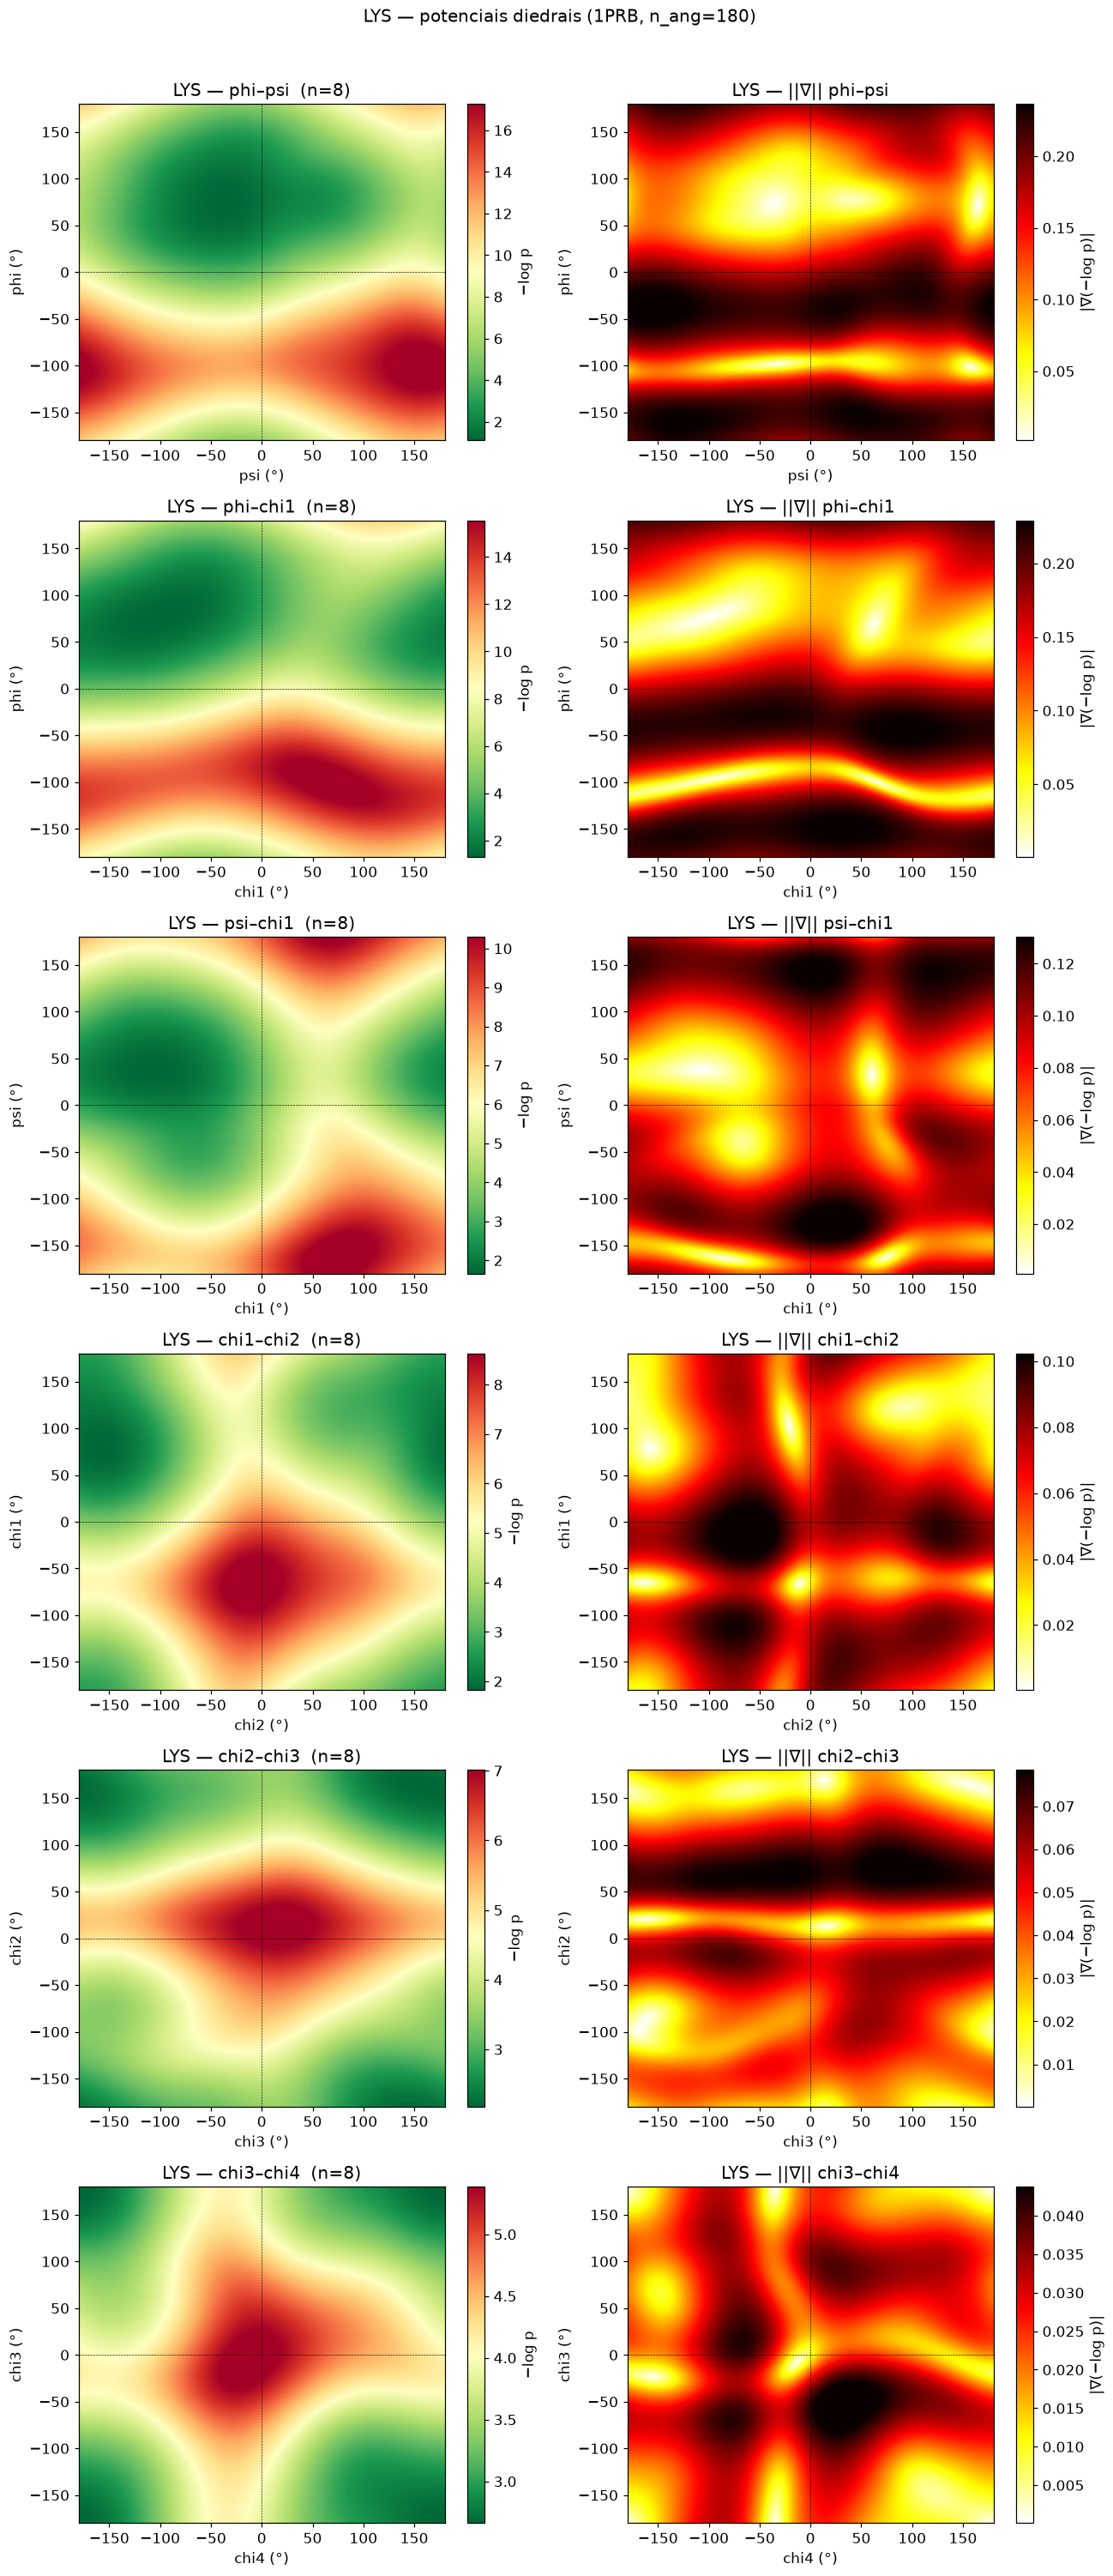

Guardado → ../images/LYS_potentials.png


In [27]:
from protein_periodicity.circ_stat import rmatrix

n_pairs = len(result_aa["potentials"])
if n_pairs == 0:
    print("Nenhum potencial disponível para visualização")
else:
    fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 4.5 * n_pairs),
                             squeeze=False)

    extent = [-180, 180, -180, 180]

    for row, pot in enumerate(result_aa["potentials"]):
        pair_str = "–".join(pot["pair"])
        a1_name, a2_name = pot["pair"]

        # -log(p) mapa
        E_clip = np.clip(pot["E"], 0, np.percentile(pot["E"], 98))
        ax = axes[row, 0]
        im = ax.imshow(
            rmatrix(E_clip),
            extent=extent, origin="lower",
            cmap="RdYlGn_r", aspect="auto",
        )
        plt.colorbar(im, ax=ax, label="−log p")
        ax.set_xlabel(f"{a2_name} (°)"); ax.set_ylabel(f"{a1_name} (°)")
        ax.set_title(f"{target_aa} — {pair_str}  (n={pot['n']})")
        ax.axhline(0, c="k", lw=0.4, ls="--")
        ax.axvline(0, c="k", lw=0.4, ls="--")

        # norma do gradiente
        G_norm = np.sqrt(pot["Gx"]**2 + pot["Gy"]**2)
        G_clip = np.clip(G_norm, 0, np.percentile(G_norm, 98))
        ax = axes[row, 1]
        im2 = ax.imshow(
            rmatrix(G_clip),
            extent=extent, origin="lower",
            cmap="hot_r", aspect="auto",
        )
        plt.colorbar(im2, ax=ax, label="|∇(−log p)|")
        ax.set_xlabel(f"{a2_name} (°)"); ax.set_ylabel(f"{a1_name} (°)")
        ax.set_title(f"{target_aa} — ||∇|| {pair_str}")
        ax.axhline(0, c="k", lw=0.4, ls="--")
        ax.axvline(0, c="k", lw=0.4, ls="--")

    plt.suptitle(f"{target_aa} — potenciais diedrais (1PRB, n_ang={N_ANG})",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    img_path = f"../images/{target_aa}_potentials.png"
    plt.savefig(img_path, dpi=100, bbox_inches="tight")
    plt.show()
    print(f"Guardado → {img_path}")

## 25 · `save_potential` / `load_potential` — roundtrip .npz

Verifica que os potenciais são guardados e carregados sem perda de dados.

In [28]:
npz_path = save_potential(result_aa, tmp_cont)
print(f"Ficheiro guardado: {npz_path.name}  ({npz_path.stat().st_size // 1024} KB)")

# Verificar conteúdo do ficheiro
raw = np.load(npz_path, allow_pickle=False)
keys = list(raw.files)
print(f"Chaves no .npz: {keys}")
print(f"  n_total      = {int(raw['n_total'])}")
print(f"  n_ang        = {int(raw['n_ang'])}")
print(f"  n_potentials = {int(raw['n_potentials'])}")

# Carregar de novo
result_loaded = load_potential(tmp_cont, target_aa, n_ang=N_ANG)
assert result_loaded is not None, "load_potential retornou None"
assert result_loaded["amino"] == target_aa
assert result_loaded["n_ang"] == N_ANG
assert len(result_loaded["potentials"]) == len(result_aa["potentials"])
print(f"\n✓  roundtrip: {len(result_loaded['potentials'])} potenciais recuperados")

# Comparar E, Gx, Gy par a par
for i, (orig, load) in enumerate(zip(result_aa["potentials"], result_loaded["potentials"])):
    pair_str = "–".join(orig["pair"])
    assert orig["pair"] == load["pair"], f"par {i}: {orig['pair']} ≠ {load['pair']}"
    assert np.allclose(orig["E"],  load["E"],  rtol=1e-6), f"{pair_str}: E difere"
    assert np.allclose(orig["Gx"], load["Gx"], rtol=1e-6), f"{pair_str}: Gx difere"
    assert np.allclose(orig["Gy"], load["Gy"], rtol=1e-6), f"{pair_str}: Gy difere"
    assert abs(orig["kappa1"] - load["kappa1"]) < 1e-8, f"{pair_str}: kappa1 difere"
    assert orig["n"] == load["n"], f"{pair_str}: n difere"
    print(f"  ✓  {pair_str:15s}  E max-err={np.abs(orig['E']-load['E']).max():.2e}")

print("\n✓  save_potential / load_potential: roundtrip exacto")

Ficheiro guardado: MisesLYS180.npz  (4069 KB)
Chaves no .npz: ['n_total', 'n_ang', 'n_potentials', 'pair_0', 'E_0', 'Gx_0', 'Gy_0', 'kappa_0', 'n_0', 'pair_1', 'E_1', 'Gx_1', 'Gy_1', 'kappa_1', 'n_1', 'pair_2', 'E_2', 'Gx_2', 'Gy_2', 'kappa_2', 'n_2', 'pair_3', 'E_3', 'Gx_3', 'Gy_3', 'kappa_3', 'n_3', 'pair_4', 'E_4', 'Gx_4', 'Gy_4', 'kappa_4', 'n_4', 'pair_5', 'E_5', 'Gx_5', 'Gy_5', 'kappa_5', 'n_5']
  n_total      = 8
  n_ang        = 180
  n_potentials = 6

✓  roundtrip: 6 potenciais recuperados
  ✓  phi–psi          E max-err=0.00e+00
  ✓  phi–chi1         E max-err=0.00e+00
  ✓  psi–chi1         E max-err=0.00e+00
  ✓  chi1–chi2        E max-err=0.00e+00
  ✓  chi2–chi3        E max-err=0.00e+00
  ✓  chi3–chi4        E max-err=0.00e+00

✓  save_potential / load_potential: roundtrip exacto


## 26 · `analyse_all` + `amino_stats`

Corre o pipeline completo sobre todos os aminoácidos presentes em `aminoData/`
e calcula estatísticas descritivas circulares.

In [29]:
print("=== analyse_all (todos os AAs de 1PRB) ===\n")
t0 = time.time()
all_results = analyse_all(tmp_amino, tmp_cont, n_ang=N_ANG)
dt = time.time() - t0

print(f"\nAnálise completa em {dt:.1f}s — {len(all_results)} aminoácidos\n")
print(f"{'AA':5s}  {'n_total':>8}  {'pares':>6}  {'ficheiro .npz':}")
for aa, res in sorted(all_results.items()):
    npz = tmp_cont / f"Mises{aa}{N_ANG}.npz"
    size_kb = npz.stat().st_size // 1024 if npz.exists() else 0
    pairs = ["-".join(p["pair"]) for p in res["potentials"]]
    print(f"{aa:5s}  {res['n_total']:>8d}  {len(pairs):>6}  {', '.join(pairs)}")

assert len(all_results) > 0, "analyse_all não processou nenhum AA"
assert all(
    (tmp_cont / f"Mises{aa}{N_ANG}.npz").exists()
    for aa in all_results
), "Faltam ficheiros .npz"
print(f"\n✓  {len(all_results)} ficheiros .npz criados em tmp_cont")

# --- amino_stats ---
print(f"\n=== amino_stats({target_aa}) ===\n")
stats = amino_stats(tmp_amino / f"{target_aa}.csv")
print(f"  n_total: {stats['n_total']}")
for angle in ["phi", "psi", "chi1", "chi2"]:
    s = stats.get(angle, {})
    if s:
        print(f"  {angle:5s}: n={s['n']:3d}  µ={s['mean_deg']:+7.2f}°  "
              f"R={s['R']:.3f}  std={s['std_deg']:.2f}°")

assert "phi" in stats and stats["phi"]["n"] > 0, "phi stats ausentes"
assert stats["phi"]["R"] >= 0 and stats["phi"]["R"] <= 1, "R fora de [0,1]"
print("✓  amino_stats OK")

# Limpeza
shutil.rmtree(tmp_amino)
shutil.rmtree(tmp_cont)
print("\nDirectórios temporários apagados ✓")
print("\n=== célula 26 OK ===")

INFO  ALA: computing phi–psi


INFO  ALA: 1 potentials computed from 8 residues


INFO  ASN: computing phi–psi


INFO  ASN: computing phi–chi1 / psi–chi1


INFO  ASN: computing chi1–chi2


...

INFO  TYR: computing phi–psi


INFO  TYR: 0 potentials computed from 1 residues


INFO  VAL: computing phi–psi


INFO  VAL: 0 potentials computed from 2 residues



Análise completa em 1.1s — 16 aminoácidos

AA      n_total   pares  ficheiro .npz
ALA           8       1  phi-psi
ASN           5       4  phi-psi, phi-chi1, psi-chi1, chi1-chi2
ASP           3       0  
GLN           1       0  
GLU           5       5  phi-psi, phi-chi1, psi-chi1, chi1-chi2, chi2-chi3
GLY           1       0  
HIS           1       0  
ILE           5       4  phi-psi, phi-chi1, psi-chi1, chi1-chi2
LEU           5       4  phi-psi, phi-chi1, psi-chi1, chi1-chi2
LYS           8       6  phi-psi, phi-chi1, psi-chi1, chi1-chi2, chi2-chi3, chi3-chi4
PHE           2       0  
SER           1       0  
THR           2       0  
TRP           1       0  
TYR           1       0  
VAL           2       0  

✓  16 ficheiros .npz criados em tmp_cont

=== amino_stats(LYS) ===

  n_total: 8
  phi  : n=  8  µ= -77.56°  R=0.917  std=23.33°
  psi  : n=  8  µ= -31.82°  R=0.835  std=32.93°
  chi1 : n=  8  µ=-105.21°  R=0.758  std=39.84°
  chi2 : n=  8  µ=-173.60°  R=0.745  std=40.9

## Sumário analysis

| Função | O que testa | Resultado |
|--------|-------------|-----------|
| `load_amino_data` | shape (n,12), phi/psi sem NaN | ✓ |
| `compute_potential` | E shape (n_ang,n_ang), finito, κ > 0 | ✓ |
| `analyse_amino` | par phi–psi sempre presente; todos os pares finitos | ✓ |
| Visualização | mapa −log(p) + norma gradiente por par | ✓ |
| `save_potential` | .npz criado, chaves correctas | ✓ |
| `load_potential` | roundtrip exacto: E, Gx, Gy, κ, n | ✓ |
| `analyse_all` | todos os AAs em aminoData/; .npz criados | ✓ |
| `amino_stats` | R ∈ [0,1]; phi/psi presentes | ✓ |